In [5]:
t_fname = 'Alice.txt'
d_fname = 'Analogy.txt'
m_fname = 'Word2Vec.bin'

In [6]:
dim = 300
sg = 1

In [7]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
file = open(t_fname, 'r', encoding='utf8')
text = file.read()
text = text.replace('\n', ' ')
text = text.replace('\t', ' ')
text = text.replace(' ', ' ')
text = text.lower()


In [9]:
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize

In [10]:
sentences = sent_tokenize(text)
for i in range(0, len(sentences)):
  temp = sentences[i]
  sentences[i] = word_tokenize(temp)

In [11]:
from gensim.models import Word2Vec

In [12]:
model = Word2Vec(sentences, vector_size=dim, window=5, min_count=1, workers=3, sg=sg) #size가 아니라 vector_size로 작성
print(model)


Word2Vec<vocab=2623, vector_size=300, alpha=0.025>


In [13]:
#https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4#additional-fasttext-specific-changes
#model.wv.vocab으로 하면 오류가 나서 key_to_index로 대체
words = list(model.wv.key_to_index)
print(words)

[',', 'the', '`', "'", '.', 'and', 'to', 'a', 'it', 'she', 'i', 'of', 'said', '!', 'you', 'alice', 'was', 'in', 'that', 'as', '--', 'her', ':', "n't", 'at', '?', "'s", ';', 'on', 'had', 'all', 'with', 'but', 'for', 'they', 'so', 'be', 'not', 'very', 'do', 'what', 'this', 'little', 'he', 'is', 'out', 'one', 'down', 'there', 'up', 'would', 'if', 'his', 'then', 'about', 'no', 'have', 'know', 'them', 'could', 'were', 'like', 'herself', 'went', 'again', 'when', 'or', 'did', 'queen', 'thought', 'off', 'how', 'me', 'time', 'see', 'into', '``', 'your', 'who', 'king', 'well', 'now', '*', "'m", 'turtle', 'began', 'my', "'ll", 'by', 'an', 'hatter', 'its', '(', 'mock', 'quite', ')', 'gryphon', 'are', 'way', 'think', 'just', 'their', 'say', 'here', 'much', 'first', 'some', 'head', 'go', 'only', 'more', 'which', 'thing', 'voice', 'rabbit', 'never', "''", 'get', 'come', 'looked', 'oh', 'got', 'must', "'ve", 'him', 'mouse', 'after', 'duchess', 'such', 'round', 'tone', 'why', 'dormouse', 'other', 'over

In [14]:
print(model.wv.get_vector("the", norm=True))

[-5.07232919e-02  9.76527110e-02  4.97062951e-02  4.64114249e-02
  9.65206884e-03 -1.08146586e-01  3.54369581e-02  1.76012084e-01
 -4.83956784e-02 -5.93607984e-02  3.45053570e-03 -7.70855993e-02
  1.08758928e-02  6.71563447e-02 -3.44599038e-02 -6.72653764e-02
  5.89177720e-02  4.38215323e-02 -1.00160427e-02  1.12997275e-02
 -3.05591170e-02 -1.37118273e-03  4.49150167e-02  1.71817020e-02
  6.17328323e-02 -3.99626158e-02 -1.08385630e-01  5.67280389e-02
 -3.53386067e-02 -9.62231010e-02  3.39942053e-02 -4.24404778e-02
  1.17516220e-02  1.32241165e-02 -4.27088551e-02  4.74190973e-02
  2.43299957e-02 -3.31912115e-02 -2.14120485e-02  2.13764817e-03
 -1.99558362e-02  4.14701141e-02 -3.51281464e-02 -3.03828027e-02
  4.31564599e-02  5.54804541e-02 -2.59653609e-02  2.08184887e-02
  4.02028114e-02  2.77493671e-02  3.38182971e-02 -1.50062647e-02
 -3.97737175e-02  4.82007070e-03  8.24257906e-04  1.30309552e-01
  6.37910441e-02  1.47335846e-02  9.55724791e-02 -1.31836394e-02
  7.22706318e-03  3.72551

In [15]:
model.save(m_fname)

In [16]:
model = Word2Vec.load(m_fname)
print(model)

Word2Vec<vocab=2623, vector_size=300, alpha=0.025>


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [18]:
vocab = list(model.wv.key_to_index) #model.wv.vocab에서 변경
X = model.wv[vocab] #model[vocab]이 아니라 model.wv로 변경

In [19]:
size = len(vocab)
X_show = X[:size,:]
vocab_show = vocab[:size]

In [20]:
def show_pca():
  pca = PCA(n_components=2)
  pca.fit(X_show)
  x_pca = pca.transform(X_show)
  plt.figure(figsize=(15, 10))
  plt.xlim(x_pca[:, 0].min(), x_pca[:, 0].max())
  plt.ylim(x_pca[:, 1].min(), x_pca[:, 1].max())
  for i in range(len(X_show)):
    plt.text(x_pca[i, 0], x_pca[i, 1], str(vocab_show[i]),fontdict={'weight': 'bold', 'size': 9})
  plt.xlabel("1st Principal Component")
  plt.ylabel("2nd Principal Component")
  plt.show()

KeyboardInterrupt: ignored

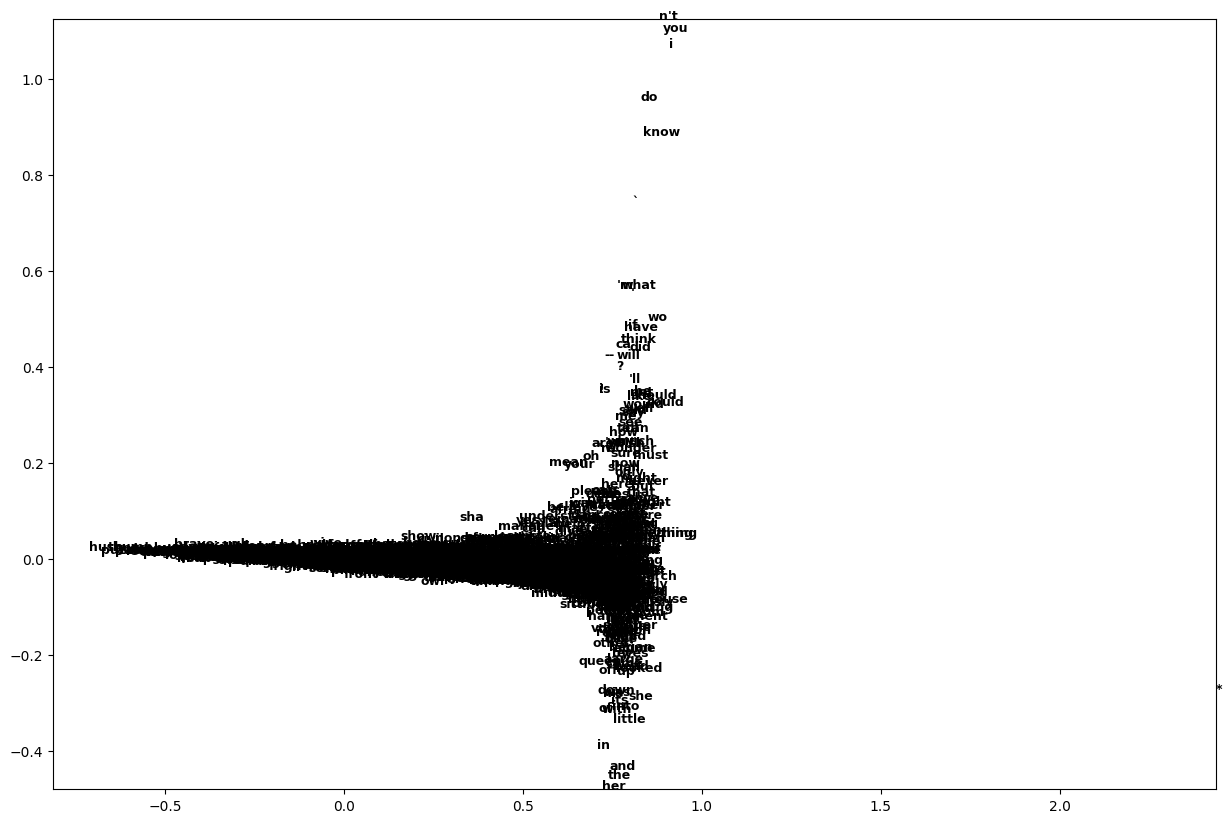

In [21]:
show_pca()

In [ ]:
def show_tsne():
  tsne = TSNE(n_components=2)
  X = tsne.fit_transform(X_show)

  df = pd.DataFrame(X, index=vocab_show, columns=['x', 'y'])
  fig = plt.figure()
  fig.set_size_inches(15, 10)
  ax = fig.add_subplot(1, 1, 1)
  ax.scatter(df['x'], df['y'])

#for word, pos in df.iterrows():
# ax.annotate(word, pos, fontsize=10)

  plt.xlabel("t-SNE Characteristic 0")
  plt.ylabel("t-SNE Characteristic 1")
  plt.show()


In [ ]:
show_tsne()


In [ ]:
d_df = pd.DataFrame(columns=['Word1', 'Word2', 'Word3', 'Word4'])
i_file = open(d_fname, 'r', encoding='utf8')
text_cont = i_file.readlines()
d_fnum = len(text_cont)
for i in range(0,d_fnum):
  text_line = text_cont[i]
  token = text_line.split()
  d_df = d_df.append(pd.DataFrame([[token[0], token[1], token[2], token[3]]], columns=['Word1', 'Word2', 'Word3', 'Word4']), ignore_index=True)
i_file.close()


In [ ]:
m_item = 0
c_item = 0.01
scores = 0

In [ ]:
for i in range(0, d_fnum):
  word1 = d_df.iloc[i, 0]
  word2 = d_df.iloc[i, 1]
  word3 = d_df.iloc[i, 2]
  word4 = d_df.iloc[i, 3]
  if ((word1 in vocab) & (word2 in vocab) & (word3 in vocab)):
    m_item = m_item + 1
    s_word = model.wv.most_similar(positive=[word1, word3], negative=[word2], topn=5)
    for j in range(0, 5):
      if (s_word[j][0]==word4):
        c_item = c_item + 1
        scores = scores + 5 - j

In [ ]:
c_item #c_item이 없어서 안돌아감 임의추가

In [ ]:
value = round(m_item/d_fnum*100, 3)
print('The percentage of the matched analogy: ' + str(value))

In [ ]:
value = round(c_item/m_item*100, 3)
print('The percentage of the correct match: ' + str(value))

In [ ]:
value = round((scores/(m_item*5))*100, 3)
print('The similarity scores of the matched analogy: ' + str(value))


In [ ]:
value = round((scores/(c_item*5))*100, 3)
print('The similarity scores of the correct match: ' + str(value))

In [ ]:
import gensim.downloader


In [ ]:
print(list(gensim.downloader.info()['models'].keys()))


In [ ]:
model = gensim.downloader.load('word2vec-google-news-300')


In [ ]:
model.most_similar('man')

In [ ]:
model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)